### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

### Unsloth

In [ ]:
import wandb
from google.colab import userdata
from huggingface_hub import login


hugging_face_token = userdata.get('HF_TOKEN')
wnb_token = userdata.get('wnb')

# Login to Hugging Face
login(hugging_face_token)

# Login to WnB
wandb.login(key=wnb_token)
run = wandb.init(
    project='Qwen3-0.6B-LABD-2.0',
    job_type="training"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: moazeldegwy (moazeldegwy-aou-egypt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 6144

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-0.6B",
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit = False,
    load_in_8bit = False,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.9: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-0.6B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 64,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 128,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.9 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


### Data Prep

In [ ]:
from datasets import load_dataset, Dataset
from unsloth.chat_templates import standardize_sharegpt
import pandas as pd

# 1. Load
tra_dataset = load_dataset("moazeldegwy/MBPP-LABD-Qwen3-0.6B", split="train")
val_dataset = load_dataset("moazeldegwy/MBPP-LABD-Qwen3-0.6B", split="test")

README.md:   0%|          | 0.00/893 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.01M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/258k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/411 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/109 [00:00<?, ? examples/s]

In [ ]:
# 1. Standardize
tra_dataset = standardize_sharegpt(tra_dataset)
val_dataset = standardize_sharegpt(val_dataset)

# 2. System prompt
sys_instruction_xml = """You are a Self-Correcting Python Agent. Solve the problem; the sandbox tool will verify your code.

### OUTPUT FORMAT
After your reasoning, output ONE <execute> block containing the function plus the user's assert statements appended verbatim. Nothing else after it.

Example:
<execute>
def add(a, b):
    return a + b

assert add(2, 3) == 5
</execute>

### RULES
- Exactly one <execute> block per turn. Function and asserts together, never split into separate blocks.
- On a debugging turn: quote Expected vs Actual from the sandbox tool feedback in your reasoning and identify the root cause before writing the corrected <execute> block.
"""


def add_system_prompt(example):
    convo = list(example["conversations"])
    if convo and convo[0]["role"] == "system":
        convo[0] = {"role": "system", "content": sys_instruction_xml}
    else:
        convo = [{"role": "system", "content": sys_instruction_xml}] + convo
    return {"conversations": convo}

tra_dataset = tra_dataset.map(add_system_prompt)
val_dataset = val_dataset.map(add_system_prompt)


# 3. Apply Qwen3 chat template once per full conversation
def to_text(example):
    return {"text": tokenizer.apply_chat_template(
        example["conversations"], tokenize=False
    )}

tra_dataset = tra_dataset.map(to_text, remove_columns=tra_dataset.column_names)
val_dataset = val_dataset.map(to_text, remove_columns=val_dataset.column_names)
tra_dataset = tra_dataset.shuffle(seed=3407)

# VERIFY: find a multi-turn example and confirm prior <think> is preserved
multi = next(
    (x for x in tra_dataset if x["text"].count("<|im_start|>assistant") >= 2),
    tra_dataset[0],
)
print(multi["text"])
print(f"\nAssistant turns: {multi['text'].count('<|im_start|>assistant')}")
print(f"<think> blocks:  {multi['text'].count('<think>')}   "
      f"(should equal assistant-turn count)")
print(f"<tool_response>: {multi['text'].count('<tool_response>')}")
assert "<feedback>" not in multi["text"], "feedback tag still leaking through"
print(f"\nTrain: {len(tra_dataset)} | Val: {len(val_dataset)}")

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/411 [00:00<?, ? examples/s]

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/109 [00:00<?, ? examples/s]

Map:   0%|          | 0/411 [00:00<?, ? examples/s]

Map:   0%|          | 0/109 [00:00<?, ? examples/s]

Map:   0%|          | 0/411 [00:00<?, ? examples/s]

Map:   0%|          | 0/109 [00:00<?, ? examples/s]

<|im_start|>system
You are a Self-Correcting Python Agent. Solve the problem; the sandbox tool will verify your code.

### OUTPUT FORMAT
After your reasoning, output ONE <execute> block containing the function plus the user's assert statements appended verbatim. Nothing else after it.

Example:
<execute>
def add(a, b):
    return a + b

assert add(2, 3) == 5
</execute>

### RULES
- Exactly one <execute> block per turn. Function and asserts together, never split into separate blocks.
- On a debugging turn: quote Expected vs Actual from the sandbox tool feedback in your reasoning and identify the root cause before writing the corrected <execute> block.
<|im_end|>
<|im_start|>user
Problem: Write a python function to find sum of products of all possible subarrays.

Test Cases:
assert sum_Of_Subarray_Prod([1,2,3],3) == 20
assert sum_Of_Subarray_Prod([1,2],2) == 5
assert sum_Of_Subarray_Prod([1,2,3,4],4) == 84<|im_end|>
<|im_start|>assistant
<think>
Okay, I need to write a Python function th

In [ ]:
# Set your limit (ensure this matches your model loading config)
def count_tokens(examples):
    """
    Tokenizes the formatted 'text' column to calculate the exact token count.
    """
    inputs = tokenizer(examples["text"], add_special_tokens = False)
    return {"length": [len(ids) for ids in inputs["input_ids"]]}

# 1. Calculate lengths for all examples
print("Counting tokens...")
tra_dataset = tra_dataset.map(count_tokens, batched = True)
val_dataset = val_dataset.map(count_tokens, batched = True)

# 2. Print Pre-Filter Statistics
print(f"\n--- Pre-Filter Stats ---")
print(f"Train Size: {len(tra_dataset)}")
print(f"Val Size:   {len(val_dataset)}")

# 3. Apply the Filter
print(f"\nFiltering out examples > {MAX_SEQ_LENGTH} tokens...")
tra_dataset = tra_dataset.filter(lambda x: x["length"] <= MAX_SEQ_LENGTH)
val_dataset = val_dataset.filter(lambda x: x["length"] <= MAX_SEQ_LENGTH)

# 4. Print Post-Filter Statistics
print(f"\n--- Post-Filter Stats ---")
print(f"Train Size: {len(tra_dataset)}")
print(f"Val Size:   {len(val_dataset)}")

Counting tokens...


Map:   0%|          | 0/411 [00:00<?, ? examples/s]

Map:   0%|          | 0/109 [00:00<?, ? examples/s]


--- Pre-Filter Stats ---
Train Size: 411
Val Size:   109

Filtering out examples > 6144 tokens...


Filter:   0%|          | 0/411 [00:00<?, ? examples/s]

Filter:   0%|          | 0/109 [00:00<?, ? examples/s]


--- Post-Filter Stats ---
Train Size: 411
Val Size:   109


In [ ]:
val_dataset[6]

{'text': '<|im_start|>system\nYou are a Self-Correcting Python Agent. Solve the problem; the sandbox tool will verify your code.\n\n### OUTPUT FORMAT\nAfter your reasoning, output ONE <execute> block containing the function plus the user\'s assert statements appended verbatim. Nothing else after it.\n\nExample:\n<execute>\ndef add(a, b):\n    return a + b\n\nassert add(2, 3) == 5\n</execute>\n\n### RULES\n- Exactly one <execute> block per turn. Function and asserts together, never split into separate blocks.\n- On a debugging turn: quote Expected vs Actual from the sandbox tool feedback in your reasoning and identify the root cause before writing the corrected <execute> block.\n<|im_end|>\n<|im_start|>user\nProblem: Write a function to check if there is a subset with sum divisible by m.\n\nTest Cases:\nassert modular_sum([3, 1, 7, 5], 4, 6) == True\nassert modular_sum([1, 7], 2, 5) == False\nassert modular_sum([1, 6], 2, 5) == False<|im_end|>\n<|im_start|>assistant\n<think>\nOkay, let\

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [ ]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = tra_dataset,
    eval_dataset = val_dataset,
    packing = False,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=1)],
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 16,
        warmup_steps = 10,
        num_train_epochs = 5,
        learning_rate = 5e-5,
        logging_steps = 1,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        per_device_eval_batch_size = 1,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
        save_total_limit = 3,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        gradient_checkpointing = True,
        report_to = "wandb",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/411 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/109 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=6):   0%|          | 0/411 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/411 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/109 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/109 [00:00<?, ? examples/s]

In [ ]:
# Find a multi-turn example and count <think> blocks in the active-loss region
multi_idx = next(
    i for i, ex in enumerate(trainer.train_dataset)
    if sum(1 for lbl in ex["labels"] if lbl != -100) > 0
    and tokenizer.decode([t for t in ex["input_ids"]]).count("<|im_start|>assistant") >= 2
)
ex = trainer.train_dataset[multi_idx]
active = tokenizer.decode([t for t, l in zip(ex["input_ids"], ex["labels"]) if l != -100])
masked = tokenizer.decode([t for t, l in zip(ex["input_ids"], ex["labels"]) if l == -100])

print(f"Example #{multi_idx}")
print(f"<think> in active region:  {active.count('<think>')}")
print(f"<execute> in active region: {active.count('<execute>')}")
print(f"<tool_response> in active region (should be 0): {active.count('<tool_response>')}")
print(f"<tool_response> in masked region: {masked.count('<tool_response>')}")

Example #1
<think> in active region:  2
<execute> in active region: 3
<tool_response> in active region (should be 0): 0
<tool_response> in masked region: 2


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
1.305 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 411 | Num Epochs = 5 | Total steps = 65
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 40,370,176 of 636,420,096 (6.34% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,0.345600,0.348486
2,0.363400,0.327981
3,0.292400,0.322161
4,0.324600,0.321076


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Epoch,Training Loss,Validation Loss
1,0.345600,0.348486
2,0.363400,0.327981
3,0.292400,0.322161
4,0.324600,0.321076
5,0.300600,0.320932


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

3566.8151 seconds used for training.
59.45 minutes used for training.
Peak reserved memory = 9.098 GB.
Peak reserved memory for training = 7.793 GB.
Peak reserved memory % of max memory = 62.473 %.
Peak reserved memory for training % of max memory = 53.512 %.


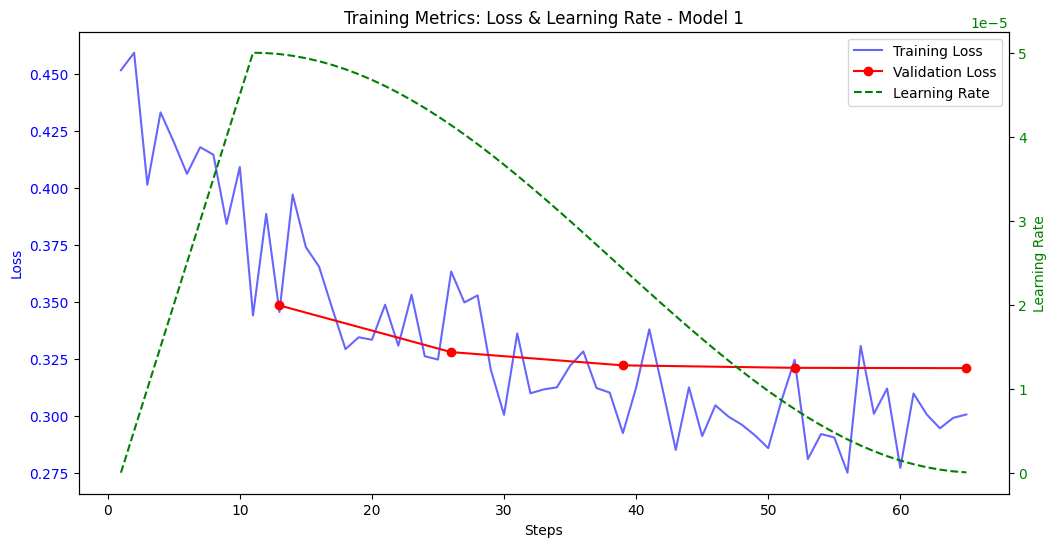

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
fig, ax1 = plt.subplots(figsize=(12, 6))

train_data = history.dropna(subset=['loss'])
ax1.plot(train_data['step'], train_data['loss'], label='Training Loss', color='blue', alpha=0.6)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

if 'eval_loss' in history.columns:
    eval_data = history.dropna(subset=['eval_loss'])
    if not eval_data.empty:
        ax1.plot(eval_data['step'], eval_data['eval_loss'], label='Validation Loss', color='red', marker='o')
    else:
        print("No validation logs found yet.")
else:
    print("Validation loss column not found in history.")

ax2 = ax1.twinx()
ax2.plot(train_data['step'], train_data['learning_rate'], label='Learning Rate', color='green', linestyle='--')
ax2.set_ylabel('Learning Rate', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Training Metrics: Loss & Learning Rate - Model 1')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

### Inference


In [ ]:
from transformers import TextStreamer

# 1. Build conversation with the system prompt
messages = [
    {"role": "system", "content": sys_instruction_xml},
    {"role": "user",   "content": "Problem: Write a function to count the element frequency in the mixed nested tuple.\n\nTest Cases:\nassert count_element_freq((5, 6, (5, 6), 7, (8, 9), 9) ) == {5: 2, 6: 2, 7: 1, 8: 1, 9: 2}\nassert count_element_freq((6, 7, (6, 7), 8, (9, 10), 10) ) == {6: 2, 7: 2, 8: 1, 9: 1, 10: 2}\nassert count_element_freq((7, 8, (7, 8), 9, (10, 11), 11) ) == {7: 2, 8: 2, 9: 1, 10: 1, 11: 2}"},
]

# 2. Apply Qwen3 chat template with thinking explicitly enabled
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True,
    enable_thinking = True,
)

FastLanguageModel.for_inference(model)
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 4096,
    do_sample   = True,
    temperature = 0.6,
    top_p       = 0.95,
    top_k       = 20,
    min_p       = 0.0,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
    stop_strings = ["<|im_end|>", "<|im_start|>"],
    tokenizer = tokenizer,
)

<think>
Okay, I need to write a Python function that counts the element frequencies in a mixed nested tuple. Let me think about how to approach this.

First, the input is a tuple, and I need to count how many times each element appears. The test cases show that the elements are inside other tuples, so I have to process those recursively.

So, maybe I can use a dictionary to keep track of counts. Initialize an empty dictionary. Then, iterate through each element in the tuple. For each element, check if it's already in the dictionary. If yes, increment its count. If not, add it with a count of 1.

But how to handle nested tuples? For example, if the input is ((5, 6, ...), ...), then each element might be a tuple itself. So, when processing each element, I need to check if it's a tuple, and then process its elements recursively.

So the steps would be:

1. Create a dictionary to hold the counts.
2. Loop through each element in the input tuple.
3. For each element, if it's a tuple, process

### Saving finetuned models

In [ ]:
if True:
    model.push_to_hub("moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT-Adapters")
    tokenizer.push_to_hub("moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT-Adapters")

README.md:   0%|          | 0.00/529 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 29.9kB /  162MB            

Saved model to https://huggingface.co/moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT-Adapters


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp457dk66a/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

In [ ]:
model.push_to_hub_merged(
    "moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT",
    tokenizer,
    save_method = "merged_16bit",
    token = hugging_face_token
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...BD-2.1-SFT/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT`: 100%|██████████| 1/1 [00:31<00:00, 31.57s/it]


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2.1-SFT/model.safetensors:   4%|4         | 47.9MB / 1.19GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:46<00:00, 106.29s/it]


Unsloth: Merge process complete. Saved to `/content/moazeldegwy/Qwen3-0.6B-LABD-2.1-SFT`
